In [ ]:
!pip install "transformers<5.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.8.0
    Uninstalling huggingface_hub-1.8.0:
      Successfully uninstalled huggingface_hub-1.8.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import torch
torch.device("cuda" if torch.cuda.is_available() else "cpu")

device(type='cuda')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import importlib
import transformers
importlib.reload(transformers)
print(transformers.__version__)

4.57.6


In [ ]:
MODEL_NAME = "google/gemma-3-4b-it"

In [ ]:
from transformers import pipeline, GenerationConfig

pipe = pipeline("text-generation", model=MODEL_NAME, return_full_text = False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.64G [00:00<?, ?B/s]

...

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
def generate_score(question, answer, context=[], prompts=[], min_score=0, max_score=5):
  # Note: Hanya jawab dengan sebuah angka dari {min_score} sampai {max_score} (Contoh: {max_score}). Tidak menjelaskan atau memasukkan teks lain.
    score = pipe([
        {
            "role": "system",
            "content": "Kamu adalah evaluator yang kritis, tegas, dan adil dalam memberikan jawaban dan menyesuaikan dengan fakta dan kriteria yang berlaku. Jika jawaban hanya berisi '-', kosong, atau tidak menjawab pertanyaan, maka berikan skor rendah menyesuaikan apa yang ditulis."
        }] + prompts + [
        {
            'role': 'user',
            'content': f"""
                Diberikan data terdiri atas pertanyaan, dan jawaban. evaluasi jawaban ini dan berikan skor dari {min_score} sampai dengan {max_score} dengan kriteria berikut:
                - Jawaban tidak boleh hanya berisi '-', kosong, atau tidak menjawab pertanyaan, jika demikian berikan skor {min_score}.
                - Jawaban harus sesuai dengan konteks
                - Penulisan jawaban harus sesuai dengan kaidah penulisan bahasa Indonesia dan typo pada jawabannya

                Instruksi:
                Baca pertanyaan dan jawabannya. Kemudian lakukan analisa terkait jawaban apakah memenuhi kriteria pertama atau tidak. Selanjutnya, bandingkan jawaban dengan konteks untuk melihat apakah sesuai atau tidak, jika tidak sesuai akan mendapatkan pengurangan nilai. Terakhir cek penulisan jawaban, jika tidak sesuai akan mendapatkan pengurangan nilai.

                Berikan output dalam format berikut:
                Penjelasan: <analisa jawaban berdasarkan instruksi>
                Skor: <nilai untuk jawaban dari {min_score} - {max_score}>
                \n
                Pertanyaan: {question}
                Jawaban: '{answer}'

                {"Konteks:\n" + "\n".join(context) if len(context) >= 1 else ""}
            """,
        }], max_new_tokens=1024)
    return score[0]['generated_text']

In [ ]:
def decompose(question):
    decomposition_prompt = f"""
        Dari pertanyaan kompleks berikut bagi menjadi sub-pertanyaan yang mencakup isi dari pertanyaan kompleks ini.

        Note:
        - Setiap sub-pertanyaan dipisahkan dengan tanda tanya ?
        - Jawab langsung seperti contoh tanpa ada teks tambahan
        - Susun pertanyaan tanpa menggunakan angka atau bullet. Langsung tuliskan pertanyaannya

        Contoh:
        1. Kapan dilantiknya presiden Indonesia yang melakukan program makan bergizi gratis?
        Output:
        Siapa Presiden yang melakukan program makan bergizi gratis?
        Kapan dia dilantiknya?

        2. Dimanakah pelukis Monalisa dilahirkan?
        Output:
        Siapa pelukis Monalisa?
        Dimana pelukis Monalisa dilahirkan?

        Pertanyaan:
        {question}
    """

    decomposed_question = pipe([{
        'role': 'user',
        'content': decomposition_prompt
    }], max_length=4000)
    return decomposed_question[0]['generated_text']

In [ ]:
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

def sim_embedding(q: str, a_i: str, a_j: str, threshold: float = 0.9) -> bool:

    text_i = f"Pertanyaan: {q} Jawaban: {a_i}"
    text_j = f"Pertanyaan: {q} Jawaban: {a_j}"

    emb_i = model.encode(text_i, convert_to_tensor=True)
    emb_j = model.encode(text_j, convert_to_tensor=True)

    score = util.cos_sim(emb_i, emb_j).item()
    return score >= threshold

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def consistency_assessment(question, nc = 5):
    cs = []
    user_prompt = {
      'role': 'user',
      'content': f"""
          Jawab pertanyaan berikut secara ringkas

          Pertanyaan: {question}
      """
      }
    prompt = [user_prompt]
    for i in range(nc):

        answer = pipe(prompt,
                do_sample=True,
                temperature=0.3,
                top_p=0.95,
                num_return_sequences=1,
                max_length=11000,
                max_new_tokens=1024)
        # print(f"Try {i}: {answer[0]['generated_text']}")

        same = False
        for a in cs:
            same = sim_embedding(question, answer[0]['generated_text'], a[0])
            if same == True:
                a.append(answer[0]['generated_text'])
                break

        if not same:
            cs.append([answer[0]['generated_text']])

        prompt.append({
            'role': 'assistant',
            'content': answer[0]['generated_text']
        })
        prompt.append(user_prompt)

    lens = [len(a) for a in cs]

    asc = [a for a in cs if len(a) == max(lens)]
    ac, tc = asc[0], len(asc[0]) / nc
    return lens, asc, ac, tc, prompt

def run_consistency_assessment(sub_questions):
    acs = []
    for sq in sub_questions:
        if len(sq) < 1:
            continue
        lens, asc, ac, tc, prompts = consistency_assessment(sq)

        print(f"Lens: {lens}")
        if tc >= 0.8:
            print(f"LLM Mastered sub-question: {sq}")
            acs.append({
                'sub-question': sq,
                'answer': ac,
                'mastered': True
            })
        else:
            print(f"LLM not mastered sub-question: {sq}")
            acs.append({
                'sub-question': sq,
                'answer': [],
                'mastered': False
            })
    return acs, prompts


In [ ]:
def recognition(question):
    qtype = pipe([{
        'role': 'user',
        'content': f"""
            Dari pertanyaan berikut, tentukan apakah pertanyaan ini merupakan pertanyaan kompleks atau tidak?

            Contoh:
            1. What is the birth date of the person Richard Callaghan
coached to Olympic, world, and national titles?

            Penjelasan:
            1. Pertanyaan ini memerlukan pengetahuan siapa yang dilatih Richard Callaghan dan dari situ juga memerlukan tanggal lahirnya.

            Jawab hanya dengan 0 (tidak) atau 1 (iya) tanpa ada teks tambahaan

            Pertanyaan: {question}
        """
    }])
    return qtype[0]['generated_text'][0]

In [ ]:
import pandas as pd
import os

def prepare_data(path):
    all_sheets_dict = pd.read_excel(path,
                                    sheet_name=None, skiprows=1)

    for key in all_sheets_dict.keys():
        df = all_sheets_dict[key]
        new_df = df.drop(df.columns[0], axis=1)
        all_sheets_dict[key] = new_df

    soal_list = list(all_sheets_dict.keys())[1:-1]

    for idx, num in enumerate(soal_list):
        ans_data = all_sheets_dict[num].dropna()
        ans_data

    ref_df = all_sheets_dict['Soal']
    for idx, num in enumerate(soal_list):
        data = all_sheets_dict[num].dropna()
        data = data.copy()
        data.columns = [col.replace(' ', '') for col in data.columns]
        if 'o' in data.columns: print(num)

        key = 'Soal' if 'Soal' in ref_df.loc[idx].keys() else 'Soal '

        soal = ref_df.loc[idx,key]
        kunjaw = ref_df.loc[idx,'Kunci Jawaban']
        data.loc[:,'Soal'] = soal
        data.loc[:,'Kunci Jawaban'] = kunjaw
        all_sheets_dict[num] = data


    df = pd.concat([all_sheets_dict[num] for num in soal_list], ignore_index=True)
    df.drop_duplicates()
    return df

DATASET_PATH = '/content/drive/MyDrive/THESIS-Dataset'


type_list = []
df_list = []
for filename in os.listdir(DATASET_PATH):
    file = os.path.join(DATASET_PATH, filename)
    type_list.append(filename.split("_")[-1].replace("xlsx", ""))
    data = prepare_data(file)
    df = data[['Jawaban', 'RataManual', 'Soal', 'Kunci Jawaban']]

    df = df.drop_duplicates()
    df_list.append(df)
    print(f"{filename}: {df.shape}")

merged = pd.concat(df_list, ignore_index=True)
merged.tail()

Analisis_Essay_Grading_Politik.xlsx: (532, 4)
No.3
Analisis_Essay_Grading_Olahraga.xlsx: (529, 4)
Analisis_Essay_Grading_Teknologi.xlsx: (501, 4)
Analisis_Essay_Grading_Lifestyle.xlsx: (560, 4)


,Jawaban,RataManual,Soal,Kunci Jawaban
2117,pikiran positif dapat memberi sugesti yang bai...,26.000000,Bagaimana hubungan berfikir positif terhadap p...,Otak merupakan bagian terpenting dari tubuh ma...
2118,secara psikologi berfikir positif mampu mening...,46.000000,Bagaimana hubungan berfikir positif terhadap p...,Otak merupakan bagian terpenting dari tubuh ma...
2119,positive thinking,1.000000,Bagaimana hubungan berfikir positif terhadap p...,Otak merupakan bagian terpenting dari tubuh ma...
2120,membuat kita berfikiran jernih dan sehat,8.333333,Bagaimana hubungan berfikir positif terhadap p...,Otak merupakan bagian terpenting dari tubuh ma...
2121,bila berfikir positif sadar atau tidak sadar p...,22.333333,Bagaimana hubungan berfikir positif terhadap p...,Otak merupakan bagian terpenting dari tubuh ma...


In [ ]:
import os
import pandas as pd

OUT_PATH = '/content/drive/MyDrive/rahutomo-scoring-out'
res_df = []
for idx,_ in enumerate(os.listdir(OUT_PATH)):
  res_df.append(pd.read_csv(f"{OUT_PATH}/rahutomo-scoring-out-reasoning-batch-{idx}.csv"))

all_df = pd.concat(res_df)

In [ ]:
test = merged[merged['Soal'] == all_df.iloc[-1]['Soal']]

last_answered_idx = all_df[all_df['Soal'] == all_df.iloc[-1]['Soal']]
len(last_answered_idx)

23

In [ ]:
# Ambil dari pertanyaan yang belum dieval
uneval_data = merged[~merged['Soal'].isin(all_df['Soal'])]

# Ambil dari jawaban yang belum dieval

partial_eval_data = test.iloc[len(last_answered_idx):]

uneval_df = pd.concat([partial_eval_data, uneval_data])

In [ ]:
import pandas as pd

ca_results = pd.read_csv('/content/drive/MyDrive/rahutomo-reasoning-out.csv')
ca_results.head()

,sub-question,answer,mastered,question,type
0,Apa yang anda ketahui mengenai MEA? (Usahakan ...,[],False,Apa yang anda ketahui mengenai MEA? (Usahakan ...,simple
1,Jelaskan yang dimaksud dengan gaya hidup hedon...,['Hedonisme adalah gaya hidup yang menekankan ...,True,Jelaskan yang dimaksud dengan gaya hidup hedon...,simple
2,"Apa perbedaan dari data, informasi dan pengeta...",['Berikut adalah perbedaan singkat antara data...,True,"Apa perbedaan dari data, informasi dan pengeta...",simple
3,Apa definisi pengakuan de facto suatu negara?,['Pengakuan de facto suatu negara berarti peng...,True,Apa yang dimaksud dengan pengakuan de facto su...,complex
4,Unsur apa saja yang harus ada agar suatu negar...,['Agar suatu negara diakui secara *de facto* (...,True,Apa yang dimaksud dengan pengakuan de facto su...,complex


In [ ]:
import numpy as np

batch_idxs = np.linspace(0, len(merged['Soal']), 41, dtype=int)
print(batch_idxs)

[   0   53  106  159  212  265  318  371  424  477  530  583  636  689
  742  795  848  901  954 1007 1061 1114 1167 1220 1273 1326 1379 1432
 1485 1538 1591 1644 1697 1750 1803 1856 1909 1962 2015 2068 2122]


In [ ]:
import numpy as np

batch_idxs = np.linspace(0, len(uneval_df['Soal']), 41 - len(res_df), dtype=int)
print(batch_idxs)

[   0   53  106  159  212  265  318  371  424  477  530  583  636  689
  742  795  848  901  954 1007 1061]


In [ ]:
import re

for idx in range(0, len(batch_idxs) - 1):
    scores = []
    for i in range(batch_idxs[idx], batch_idxs[idx+1]):

      data = uneval_df.iloc[i]
      question = data['Soal']
      # ty = recognition(question)
      # print(ty)
      # if ty == '1':
      #     print(f"Complex question: {question}")
      #     sub_questions = decompose(question).split('\n')
      # else:
      #     print("Simple question")
      #     sub_questions = [question]
      # answer, prompts = run_consistency_assessment(sub_questions)
      def user_prompt(q):
         return {
        'role': 'user',
        'content': f"""
            Jawab pertanyaan berikut secara ringkas

            Pertanyaan: {q}
        """
        }
      prompts = []
      data_ca = ca_results[ca_results['question'] == data['Soal']]
      for j, row in data_ca.iterrows():
        sub_answer = row['answer'].split('\', \'')
        sub_question = row['sub-question']
        for s in sub_answer:
          ca_prompt = user_prompt(sub_question)
          ca_response = {
              'role': 'assistant',
              'content': s
          }
          prompts.append(ca_prompt)
          prompts.append(ca_response)

      score = generate_score(data['Soal'], data['Jawaban'], [data['Kunci Jawaban']], prompts,  max_score = 100)
      scores.append(score)
      print(f"Score: {data['RataManual']}, Predicted: {score}")

    saved = uneval_df.iloc[batch_idxs[idx]:batch_idxs[idx+1]]
    saved['Prediksi'] = scores
    saved.to_csv(f'/content/drive/MyDrive/rahutomo-scoring-out-reasoning-batch-{idx+len(res_df)}.csv', index=False)

Score: 45.0, Predicted: Penjelasan: Jawaban ini memberikan definisi yang cukup baik mengenai parkour, menyoroti tujuan efisiensi dan kecepatan dalam berpindah tempat. Penggunaan kata “efisien” dan “secepat-cepatnya” tepat menggambarkan esensi parkour. Penjelasan mengenai tempat-tempat yang digunakan juga relevan dengan konteks parkour (pohon, batu, tembok). Namun, ada sedikit ketidaktepatan dalam penggunaan kata "cabang-cabang pohon" yang kurang spesifik.

Skor: 85
Score: 47.333333333333336, Predicted: Penjelasan: Jawaban ini memberikan definisi yang cukup baik mengenai parkour sebagai seni melompat dan menyebutkan beberapa tempat yang umum digunakan. Namun, menyebutkan “olahraga” sedikit menyesatkan karena parkour lebih menekankan pada kemampuan bergerak dan mengatasi rintangan daripada kompetisi olahraga formal. Selain itu, penggunaan tanda kutip pada awal jawaban dan akhir jawaban tidak perlu.

Skor: 75
Score: 28.333333333333332, Predicted: Penjelasan: Jawaban ini sangat kurang memu

/tmp/ipykernel_1347/3567565999.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  saved['Prediksi'] = scores


Score: 10.0, Predicted: Penjelasan: Jawaban ini sangat singkat dan hanya menyebutkan dua fungsi umum partai politik (mengelola dan menyejahterakan masyarakat) tanpa menjelaskan hubungannya dengan kekuasaan pemerintahan. Jawaban ini tidak menjawab pertanyaan secara komprehensif dan terlalu umum.

Skor: 30
Score: 26.0, Predicted: Penjelasan: Jawaban ini relevan dengan pertanyaan karena menjelaskan fungsi partai politik yang terpilih, yaitu mengelola negara dan mewadahi berbagai golongan masyarakat. Namun, jawaban ini sedikit bertele-tele dan kurang ringkas sesuai dengan instruksi yang meminta jawaban dalam 2-4 kalimat. Selain itu, kalimat terakhir (“menjaga tatanan aparatur negara sesuai perundang-undangan yang berlaku”) terasa kurang relevan dengan fokus utama pertanyaan mengenai kekuasaan pemerintahan.

Skor: 75
Score: 8.333333333333334, Predicted: Penjelasan: Jawaban ini tidak menjawab pertanyaan yang diajukan. Pertanyaan meminta penjelasan mengenai *fungsi* partai politik, sedangkan 

/tmp/ipykernel_1347/3567565999.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  saved['Prediksi'] = scores


Score: 77.33333333333333, Predicted: Penjelasan: Jawaban ini sebagian mencerminkan isi Proklamasi, namun terdapat beberapa ketidaksesuaian dan kurang lengkap.  Pernyataan mengenai pemindahan kekuasaan dan tanggalnya (17-8-05) tidak relevan dengan inti Proklamasi.  Selain itu, terdapat beberapa typo dan penggunaan tanda baca yang kurang tepat. Meskipun memberikan sebagian informasi penting, jawaban ini tidak sepenuhnya merepresentasikan isi Proklamasi yang lengkap dan sesuai dengan ejaan yang disempurnakan.

Skor: 65
Score: 70.33333333333333, Predicted: Penjelasan: Jawaban ini sebagian mencerminkan isi Proklamasi, namun kurang lengkap dan terdapat beberapa ketidaksesuaian dengan teks asli.  Kalimat yang diberikan merupakan potongan dari Proklamasi, tetapi tidak menyertakan seluruh isi dan tidak menggunakan ejaan yang telah disempurnakan sepenuhnya (misalnya, penggunaan "d.l.l." dan "tempo yang sesingkat-singkatnya" kurang tepat).  Selain itu, format penyajian jawaban juga kurang baik.



...

/tmp/ipykernel_1347/3567565999.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  saved['Prediksi'] = scores


Score: 43.333333333333336, Predicted: Penjelasan: Jawaban ini tidak hanya berisi daftar nama versi Android, tetapi juga menyertakan informasi tambahan seperti nama kode (Astro, Bender, dll.) yang relevan. Meskipun konteks meminta hanya nama versi, informasi tambahan ini meningkatkan nilai jawaban. Penulisan bahasa Indonesia juga baik dan tidak terdapat typo. Namun, konteks menyebutkan hingga "saat ini", dan jawaban tidak mencakup semua versi hingga saat ini (misalnya, Marshmallow, Nougat, Oreo, Pie, Q, R, S, T, U, V, W, X, Y, Z dan Android 30).

Skor: 75
Score: 84.33333333333333, Predicted: Penjelasan: Jawaban ini tidak hanya berisi daftar nama versi Android, tetapi juga menyertakan kutipan tunggal (‘’). Meskipun secara teknis menjawab pertanyaan, formatnya kurang ideal dan kurang ringkas. Selain itu, terdapat kesalahan dalam menyebutkan “kit kat” alih-alih “KitKat”.  Meskipun daftar versi yang disebutkan umumnya benar, penulisan yang kurang sempurna mengurangi nilai.

Skor: 75
Score: 

/tmp/ipykernel_1347/3567565999.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  saved['Prediksi'] = scores


Score: 53.333333333333336, Predicted: Penjelasan: Jawaban ini memberikan definisi topologi jaringan LAN dan menyebutkan contoh-contoh topologi yang relevan (bus, star, ring). Penulisan bahasa Indonesia juga sudah cukup baik dan tidak terdapat typo. Namun, jawaban ini kurang detail dalam menjelaskan apa yang dimaksud dengan topologi.

Skor: 85
Score: 32.333333333333336, Predicted: Penjelasan: Jawaban ini memberikan definisi topologi jaringan LAN dan menyebutkan contoh topologi (ring, bus, tree) yang relevan dengan konteks yang diberikan. Penulisan bahasa Indonesia juga cukup baik dan tidak terdapat typo.
Skor: 90
Score: 47.666666666666664, Predicted: Penjelasan: Jawaban ini memenuhi kriteria karena tidak hanya berisi "-", kosong, atau tidak menjawab pertanyaan. Jawaban tersebut secara akurat mendefinisikan topologi jaringan LAN dan memberikan contoh-contoh yang relevan (Star, Mesh, Hirarki). Penulisan bahasa Indonesia juga baik dan tidak terdapat typo. Jawaban juga sesuai dengan konteks

/tmp/ipykernel_1347/3567565999.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  saved['Prediksi'] = scores


In [ ]:
import re

for idx in range(0, len(batch_idxs) - 1):
    scores = []
    for i in range(batch_idxs[idx], batch_idxs[idx+1]):

      data = merged.iloc[i]
      question = data['Soal']
      # ty = recognition(question)
      # print(ty)
      # if ty == '1':
      #     print(f"Complex question: {question}")
      #     sub_questions = decompose(question).split('\n')
      # else:
      #     print("Simple question")
      #     sub_questions = [question]
      # answer, prompts = run_consistency_assessment(sub_questions)
      def user_prompt(q):
         return {
        'role': 'user',
        'content': f"""
            Jawab pertanyaan berikut secara ringkas

            Pertanyaan: {q}
        """
        }
      prompts = []
      data_ca = ca_results[ca_results['question'] == data['Soal']]
      for j, row in data_ca.iterrows():
        sub_answer = row['answer'].split('\', \'')
        sub_question = row['sub-question']
        for s in sub_answer:
          ca_prompt = user_prompt(sub_question)
          ca_response = {
              'role': 'assistant',
              'content': s
          }
          prompts.append(ca_prompt)
          prompts.append(ca_response)

      score = generate_score(data['Soal'], data['Jawaban'], [data['Kunci Jawaban']], prompts,  max_score = 100)
      scores.append(score)
      print(f"Score: {data['RataManual']}, Predicted: {score}")

    saved = merged.iloc[batch_idxs[idx]:batch_idxs[idx+1]]
    saved['Prediksi'] = scores
    saved.to_csv(f'/content/drive/MyDrive/rahutomo-scoring-out-reasoning-batch-{idx}.csv', index=False)

Score: 79.33333333333333, Predicted: Penjelasan: Jawaban ini memberikan penjelasan yang cukup komprehensif mengenai kegunaan karbohidrat, mencakup peran metabolisme, pembentukan jaringan, pencegahan ketidakseimbangan asam basa, pemasok energi, dan pengaruh terhadap protein. Jawaban ini juga menyertakan informasi tentang kandungan kalori dan manfaat serat. Namun, terdapat beberapa pengulangan dan kalimat yang kurang ringkas. Meskipun informasinya relevan, penyampaiannya bisa lebih padat.

Skor: 85
Score: 18.333333333333332, Predicted: Penjelasan: Jawaban ini sangat singkat dan tidak menjelaskan kegunaan karbohidrat secara komprehensif. Hanya menyebutkan satu fungsi, yaitu mencegah rasa lapar, dan tidak menyentuh aspek penting lainnya seperti penyediaan energi, pencernaan, atau keseimbangan asam basa. Jawaban ini juga kurang informatif dibandingkan konteks yang diberikan.

Skor: 30
Score: 19.666666666666668, Predicted: Penjelasan: Jawaban ini menjawab pertanyaan, namun terlalu singkat da

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Score: 46.666666666666664, Predicted: Penjelasan: Jawaban ini memberikan beberapa poin yang relevan mengenai manfaat telur, namun tidak secara spesifik hanya merinci 4 manfaat utama seperti yang diminta dalam pertanyaan. Penjelasan mengenai masker wajah dan manfaat lainnya tidak relevan dengan fokus pertanyaan. Penulisan juga kurang rapi dengan penggunaan tanda kutip di dalam teks.

Skor: 65
Score: 23.333333333333332, Predicted: Penjelasan: Jawaban ini memberikan beberapa informasi tentang kandungan telur, namun tidak secara eksplisit dan ringkas menjelaskan 4 manfaat kesehatan telur secara umum. Informasi mengenai kolesterol dan kandungan nutrisi lainnya relevan, tetapi tidak terstruktur sebagai daftar manfaat. Selain itu, terdapat beberapa kesalahan tata bahasa dan penggunaan kata yang kurang tepat ("nutrisi-nutrisi tersebut kaya tinggi").

Skor: 65
Score: 9.333333333333334, Predicted: Penjelasan: Jawaban ini tidak sepenuhnya memenuhi kriteria. Meskipun menyebutkan beberapa manfaat t

/tmp/ipykernel_1784/3045445886.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  saved['Prediksi'] = scores


Score: 20.666666666666668, Predicted: Penjelasan: Jawaban ini tidak hanya berisi tanda '-'. Meskipun menyebutkan beberapa manfaat telur, penjelasannya kurang rinci dan terstruktur. Beberapa poin yang disebutkan relevan dengan kesehatan (daya tahan tubuh, meningkatkan protein, tubuh sehat, tidak mudah lesu), namun tidak ada penjelasan yang mendalam. Selain itu, jawaban tersebut tidak sepenuhnya sesuai dengan konteks yang diberikan, yang lebih fokus pada manfaat telur untuk kesehatan secara umum dan beberapa kondisi medis tertentu. Penulisan juga sedikit kurang rapi.
Skor: 55
Score: 29.666666666666668, Predicted: Penjelasan: Jawaban ini secara ringkas menyebutkan 4 manfaat telur untuk kesehatan, yaitu protein, energi, daya tahan tubuh, dan vitamin. Jawaban tersebut relevan dengan pertanyaan dan menggunakan bahasa Indonesia yang baik. Namun, jawaban ini kurang detail dan tidak menjelaskan *mengapa* manfaat tersebut terjadi. Informasi tambahan mengenai bagaimana setiap manfaat tersebut bek

...

Score: 48.0, Predicted: Penjelasan: Jawaban ini memberikan beberapa poin yang relevan terkait pemilihan kolam renang yang baik, seperti tempat, kondisi, lingkungan, air yang bersih, dan kedalaman yang sesuai. Meskipun tidak menyebutkan semua aspek yang disebutkan dalam konteks (misalnya, peralatan keselamatan), jawaban ini memenuhi persyaratan minimal 3 poin dan ditulis dengan baik dalam bahasa Indonesia.
Skor: 85
Score: 53.333333333333336, Predicted: Penjelasan: Jawaban memberikan tiga poin yang relevan dengan pemilihan kolam renang yang baik (kedalaman, kebersihan air, dan keramaian). Meskipun jawaban tersebut singkat, ia memenuhi instruksi untuk menyebutkan minimal 3 poin. Penulisan bahasa Indonesia juga baik dan tidak terdapat typo. Namun, jawaban tersebut kurang komprehensif dibandingkan konteks yang diberikan, yang mencakup peralatan keselamatan dan bentuk/kedalaman kolam.

Skor: 75
Score: 55.333333333333336, Predicted: Penjelasan: Jawaban ini memberikan beberapa poin yang releva

/tmp/ipykernel_1784/3045445886.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  saved['Prediksi'] = scores


Score: 93.33333333333333, Predicted: Penjelasan: Jawaban ini memenuhi semua kriteria. Jawaban tidak hanya berisi tanda baca atau kosong, melainkan secara spesifik menyebutkan 5 partai yang biasa dilombakan dalam bulu tangkis. Penulisan jawaban juga sesuai dengan kaidah bahasa Indonesia dan tidak terdapat typo. Selain itu, jawaban tersebut sesuai dengan konteks yang diberikan.

Skor: 100
Score: 98.33333333333333, Predicted: Penjelasan: Jawaban ini memenuhi kriteria pertama karena tidak hanya berisi tanda '-', kosong, atau tidak menjawab pertanyaan. Jawaban juga secara spesifik menyebutkan 5 partai yang biasa dilombakan dalam bulu tangkis. Namun, terdapat beberapa ketidaksesuaian dengan konteks yang diberikan. Penulisan jawaban kurang rapi, terdapat penggunaan tanda koma yang berlebihan dan kurang konsisten. Selain itu, penggunaan kata “campuran” tidak tepat, seharusnya menggunakan “ganda campuran”.

Skor: 75
Score: 98.33333333333333, Predicted: Penjelasan: Jawaban ini secara akurat meny

/tmp/ipykernel_1784/3045445886.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  saved['Prediksi'] = scores


Score: 45.0, Predicted: Penjelasan: Jawaban ini memberikan definisi yang cukup baik tentang parkour, menekankan efisiensi dan kecepatan. Deskripsi tempat-tempat yang bisa digunakan juga relevan dengan konteks parkour, seperti pohon, batu, dan tembok. Namun, penggunaan kata "efisian" (seharusnya "efisien") dan detail tentang "pegangan tangan dan tembok beton" terasa kurang spesifik dan sedikit mengurangi kualitas jawaban.

Skor: 75
Score: 47.333333333333336, Predicted: Penjelasan: Jawaban ini menjawab pertanyaan dengan memberikan definisi singkat mengenai parkour sebagai seni olahraga melompat, serta menyebutkan beberapa lokasi umum yang digunakan untuk melakukan parkour (gedung, jalan, jembatan). Meskipun demikian, jawaban ini kurang detail dalam menjelaskan inti dari parkour sebagai seni bergerak yang berfokus pada efisiensi dan kreativitas dalam mengatasi rintangan. Selain itu, penggunaan kata "biasanya" terasa kurang tepat karena parkour menekankan pada kemampuan individu untuk meng

In [ ]:
import numpy as np

def rmse(actual, predicted):
    return np.sqrt(((predicted - actual) ** 2).mean())

In [ ]:
labels = all_df['RataManual']
scores = [int(pred[pred.find('Skor: '):].replace('/100', '').replace('\n', '').replace('Skor: ', '')) for pred in all_df['Prediksi']]
all_df['IntScore'] = scores

res = rmse(labels, scores) / 100


In [ ]:
from scipy.stats import pearsonr
import numpy as np

r, p_value = pearsonr(scores, labels)
print(f"Pearson correlation: {r:.3f}, p-value: {p_value}")

Pearson correlation: 0.570
P-value: 2.527589798669729e-183


In [ ]:
from scipy.stats import spearmanr
import numpy as np

rho, p_value = spearmanr(labels, scores)
print(f"Spearman correlation: {rho:.3f}, p-value: {p_value}")

Spearman correlation: 0.613, p-value: 2.4679019087749138e-219


In [ ]:
print(f"RMSE: {res:.3f}")

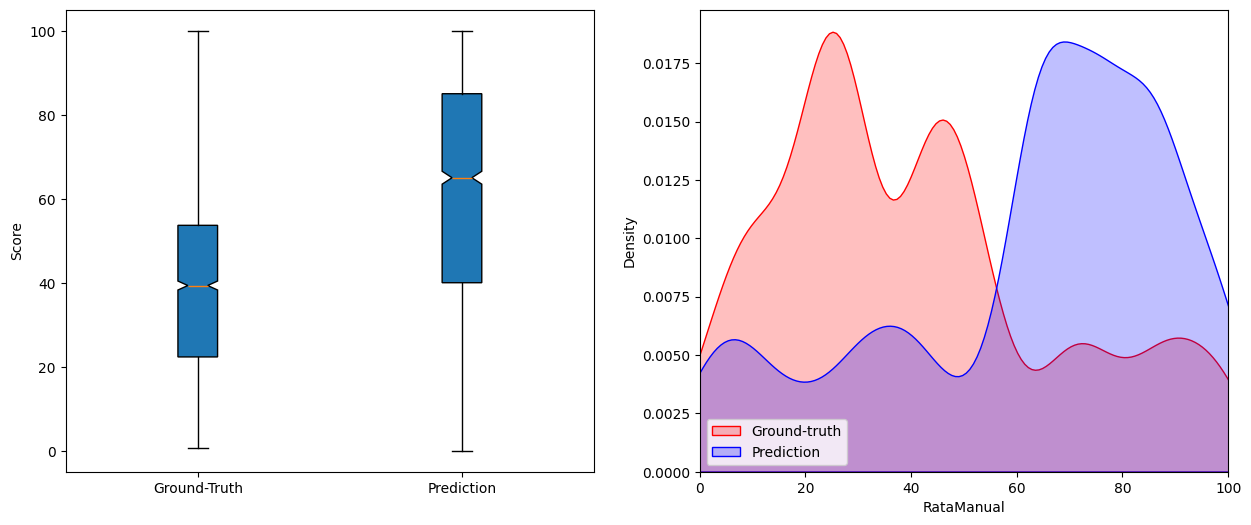

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.boxplot([labels, scores], tick_labels=['Ground-Truth', 'Prediction'], notch=True, patch_artist=True)
plt.ylabel('Score')

# plt.subplot(2,2,2)
# plt.ylabel('Score')
# plt.boxplot(scores, notch=True, patch_artist=True)
# plt.title("Prediction")

plt.subplot(1,2,2)
sns.kdeplot(data=all_df, x='RataManual', fill=True, color='red', label='Ground-truth')
sns.kdeplot(data=all_df, x='IntScore', fill=True, color='blue', label='Prediction')
plt.legend()
plt.xlim(0,100)

# plt.subplot(2,2,4)
# sns.kdeplot(data=scores, x='sepal_width', fill=True, color='skyblue')
# plt.title('Prediction')
plt.show()